In [ ]:
import sys
sys.path.append('../Code')
from CLfitter import *
from joblib import Parallel, delayed
import numpy as np
import os
import torch.nn as nn

## Config
All run parameters are defined here. Edit this cell before running the notebook.

In [6]:
config = {
    # -- file -----------------------------------------------------------
    'path':               'data/twisted-CrSBr-2deg-eels-SI_004.dm4',
    'core_loss_index':    3,
    'lowloss':            False,

    # -- energy window  (E_min, E_edge_onset, E_max) in eV --------------
    'energy_window':      (520, 570, 670),

    # -- pooling --------------------------------------------------------
    'pool_radius':        2,
    'gaussian_kernel':    True,

    # -- clustering -----------------------------------------------------
    'n_clusters':         4,

    # -- training -------------------------------------------------------
    'n_mc_replicas':      5,
    'epochs':             20000,
    'replica_version':    'covariance',  # 'triangular' | 'covariance' | 'local'
    'progress':           False,
    'logging':            False,

    # -- parallelization ------------------------------------------------
    'parallelize':        True,
    'n_jobs':             4,
    'n_runs':             4,

    # -- output ---------------------------------------------------------
    'folder_path':        'tempdata/CrSBr/background_prediction',

    # -- white line fitting ---------------------------------------------
    'L3_guess':           577,
    'L2_guess':           586,
    'fit_window':         5,
    'integration_window': 1.5,
    'fitdata_path':       'tempdata/CrSBr/WL-results',
}

# create tempdata folder if it doesn't exist
os.makedirs(config['folder_path'], exist_ok=True)
os.makedirs(config['fitdata_path'], exist_ok=True)

The first step to obtain a background prediction is defining the NN architecture. It was found that a 2,16,1 architecture works well.

In [9]:
class EELSBackgroundNN(nn.Module):
     def __init__(self):
          super().__init__()
          self.model = nn.Sequential(
               nn.Linear( 2, 16),
               nn.SiLU(),
               nn.Linear(16, 1)
          )
     def forward(self, x):
          return self.model(x)

**DataHandler** is called to handle the data.
.read_dm4_SI can obtain data from either dm3 and dm4 files, with core_loss_index begin the index of the core-loss data. This index can either be found by trail and error or opening GMS and checking the entry. Index runs from 0, so keep that in mind.

**Pooler** is used to pool the data per energy bin. Either a gaussian or a square kernel can be used, and a radius can be defined.

Due to how some EELS spectroscopes gather data, negative counts can be obtained. All entries less than 1 are therefore set to 1 (also to avoid ln(0) later on)


In [11]:
data_handler = DataHandler()
data_handler.read_dm4_SI(config['path'], core_loss_index=config['core_loss_index'], lowloss=config['lowloss'])

pooler = Pooler(data_handler.signal, data_handler.si_size)
signal = pooler.pool_data(config = config)
signal[signal < 1] = 1

Some pre-processing steps.

In [12]:
i = config['energy_window']

# Define E_min, E_I and E_max
range_mask    = (data_handler.energy_axis > i[0]) & (data_handler.energy_axis < i[-1])  # shape [n_E_1]
energy_range  = data_handler.energy_axis[range_mask]                                     # shape [n_E_1]
signal_range  = signal.copy()[range_mask, :]                                             # shape [n_E_1, n_y*n_x]
pre_edge_mask = (energy_range > i[0]) & (energy_range < i[1])                           # shape [n_E_2]

**Clusterer** clusters the data in n_clusters clusters. .cholesky_decomp calculates the cholesky decomposition of the covariance matrices.

**X_Builder** makes the X data for the NN training, both MC and evaluation. 

In [14]:
clusterer = ClusterAnalyzer(signal_range)
clusterer.cluster_data(config=config, pre_edge_mask=pre_edge_mask)
clusterer.cholesky_decomp()

X_builder = X_Builder(energy_range)
X_builder.prepare_X_mc_data(clusterer.cluster_centers, i[1])
X_builder.prepare_X_eval_data(clusterer.total_integrated_intensity)

The following cell trains the NN's and saves the results. It does this in parallel, each core running 10 NN's consecutively.

In [21]:
def train_background(ii, signal_range, pre_edge_mask, X_builder, clusterer, i, config):
    background_trainer = BackgroundTrainer(
        signal=signal_range,
        pre_edge_mask=pre_edge_mask,
        X_mc=X_builder.X_mc,
        X_eval=X_builder.X_eval,
        clustered_spectra_mean=clusterer.clusters_mean,
        triangular_matices=clusterer.triangular_matices,
        covariance_matrices=clusterer.clusters_covariance,
        cluster_labels=clusterer.clusters
    )

    background_trainer.train_MC_replica_consecutive(
        edge_onset=i[1],
        config=config,
        model=EELSBackgroundNN()
    )

    predictions = background_trainer.background

    output_path = config['folder_path']
    if ii == 0:
        np.savez(os.path.join(output_path, 'run_params.npz'),         
                 signal=signal_range,
                energy_axis=energy_range,
                spatial_axis_x=data_handler.spatial_axis_x,
                spatial_axis_y=data_handler.spatial_axis_y)
    np.save(os.path.join(output_path, f'pred_{ii}.npy'),         
            predictions)

    del background_trainer
    import gc
    gc.collect()


if config['parallelize']:
    Parallel(n_jobs=config['n_jobs'])(
        delayed(train_background)(ii, signal_range, pre_edge_mask, X_builder, clusterer, i, config)
        for ii in range(config['n_runs'])
    )
else:
    for ii in range(config['n_runs']):
        train_background(ii, signal_range, pre_edge_mask, X_builder, clusterer, i, config)

In [9]:
from lmfit import Model, Parameters
def _two_gauss_two_arctan(x,
                        A1, mu1, sigma1,
                        A2, mu2, sigma2,
                        C1, x01, w1,
                        C2, x02, w2):
    """
    Model = 2 Gaussians + 2 shifted arctan steps).
    """
    g1 = A1 * np.exp(-(x - mu1) ** 2 / (2 * sigma1 ** 2))
    g2 = A2 * np.exp(-(x - mu2) ** 2 / (2 * sigma2 ** 2))
    ar1 = C1 * (np.arctan((x - x01) / (w1 + 1e-12)) + np.pi / 2.0)
    ar2 = C2 * (np.arctan((x - x02) / (w2 + 1e-12)) + np.pi / 2.0)
    return g1 + g2 + ar1 + ar2


def _fit_and_integrate_white_lines(energy_axis, spectrum, mu_guesses, fit_window=5.0, integration_window=1.5):
    """
    LMfit: fit spectrum with 2 Gaussians + 2 shifted arctans.
    Returns: area1, area2, mu1, mu2, (step1_height, step2_height)
    """
    energy = energy_axis
    mask_fit = (energy > min(mu_guesses) - fit_window) & (energy < max(mu_guesses) + fit_window)
    x = energy[mask_fit]
    y = spectrum[mask_fit]

    if len(x) < 5 or np.all(y <= 0):
        return np.nan, np.nan,np.nan, np.nan,np.nan, np.nan,np.nan, np.nan

    # Initial guesses
    A1_guess = max(y[(x > mu_guesses[0]-0.5) & (x < mu_guesses[0]+0.5)].max(), 1e-3)
    A2_guess = max(y[(x > mu_guesses[1]-0.5) & (x < mu_guesses[1]+0.5)].max(), 1e-3)
    C_guess = max((y[-1] - y[0]) * 0.3, 1e-3)

    model = Model(_two_gauss_two_arctan)
    params = Parameters()

    #sharpness
    params.add("A1", value=A1_guess, min=0)
    params.add("A2", value=A2_guess, min=0)

    params.add("C1", value=C_guess, min=1)
    params.add("C2", value=C_guess, min=1)
   
    #sharpness
    params.add("sigma1", value=0.7, min=0.1, max=2.0)
    params.add("sigma2", value=0.7, min=0.1, max=2.0)

    params.add("w1", value=0.5, min=0.01, max=2)

    params.add("delta_w", value=0.0, min=-0.5, max=0.5)  # allow ±0.5 eV difference
    params.add("w2", expr="w1+delta_w")

    #onsets
    params.add("mu1", value=mu_guesses[0], min=mu_guesses[0]-2, max=mu_guesses[0]+2)
    params.add("mu2", value=mu_guesses[1], min=mu_guesses[1]-2, max=mu_guesses[1]+2)

    params.add('deltax01', value=0, min=-1, max=1)
    params.add("x01", expr = 'mu1+deltax01')
    params.add('deltax02', value=0, min=-1, max=1)
    params.add("x02", expr = 'mu2+deltax02')
    
    try:
        result = model.fit(y, params, x=x)
        best = result.best_values
        fit_y = result.best_fit

        mu1, mu2 = best["mu1"], best["mu2"]
        C1, x01, w1 = best["C1"], best["x01"], best["w1"]
        C2, x02, w2 = best["C2"], best["x02"], best["w2"]
        A1, A2, sigma1, sigma2 = best['A1'], best['A2'], best['sigma1'], best['sigma2']

        return C1, C2, A1, A2, sigma1, sigma2, mu1, mu2

    except Exception:
        print('bonk')
        return np.nan, np.nan,np.nan, np.nan,np.nan, np.nan,np.nan, np.nan

def _fit_single_pixel(spectrum, energy_range, mu_guess):
    """
    Fit a single pixel spectrum using your 2Gauss+2Arctan model.
    Reuses mu_guess to stabilize convergence.
    Returns the white-line intensity and updated mu_guess.
    """
    C1, C2, A1, A2, sigma1, sigma2, mu1, mu2 = _fit_and_integrate_white_lines(
        energy_range, spectrum, mu_guess
    )

    wl_intensity = (A1 * sigma1 - A2 * sigma2) / (C1 + C2) if not np.isnan(mu1) else np.nan

    # Update guess for next pixel
    if not np.isnan(mu1):
        mu_guess = (mu1, mu2)

    return wl_intensity, mu_guess


def _process_replica(signal_bg, energy_range):
    """
    Process one replica (all pixels) sequentially with parameter reuse.
    """
    n_pix = signal_bg.shape[0]
    wl_replica = np.zeros(n_pix)
    mu_guess = (577, 586)  # initial guess for first pixel

    for i in range(n_pix):
        spectrum = signal_bg[i, :]
        wl_replica[i], mu_guess = _fit_single_pixel(spectrum, energy_range, mu_guess)

    return wl_replica


def _process_file(file_idx, signal_range, energy_range):
    """
    Process one file:
      - Load predictions
      - Subtract background
      - Fit all replicas
      - Save WL results
    """
    predictions = np.load(f'{config["folder_path"]}/pred_{file_idx}.npy')
    n_replicas = len(predictions)
    n_pix = signal_range.shape[1]

    WL = np.zeros((n_replicas, n_pix))

    for xx, prediction in enumerate(predictions):
        # Background subtraction
        signal_bg = signal_range.T - prediction
        signal_bg[signal_bg < 0] = 0  # optional clipping

        # Fit all pixels in this replica sequentially with parameter reuse
        WL[xx] = _process_replica(signal_bg, energy_range)

    # Save results
    np.save(f'{config["fitdata_path"]}/results_{file_idx}', WL)
    return f"File {file_idx} done"

energy_range = np.load(f'{config["folder_path"]}/run_params.npz')['energy_axis']
signal_range = np.load(f'{config["folder_path"]}/run_params.npz')['signal']

n_files = config['n_runs']  
WL_results = Parallel(n_jobs=4)(
    delayed(_process_file)(ii, signal_range, energy_range) for ii in range(n_files)
)

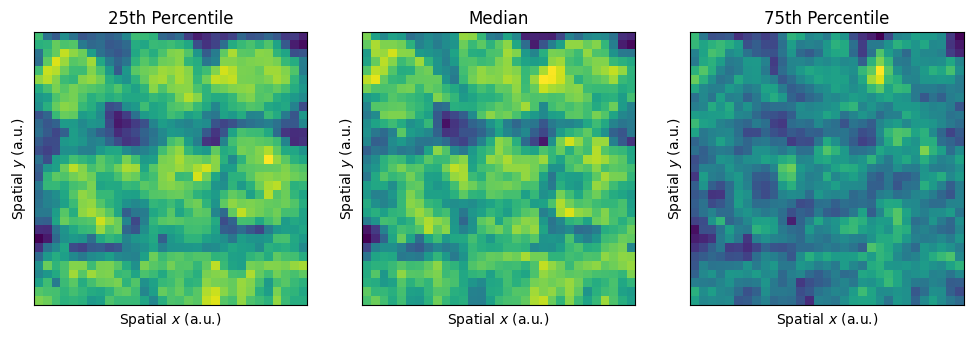

In [16]:
import numpy as np
import os
from glob import glob

# folder containing WL result files
folder = config['fitdata_path'] 
file_pattern = os.path.join(folder, "results_*.npy")

# collect WL arrays from files that exist
wl_list = []

for file_path in glob(file_pattern):
    try:
        wl = np.load(file_path)  # shape [n_replicas, n_pix]
        wl_list.append(wl)
    except Exception:
        print(f"Skipping missing or corrupted file: {file_path}")

# combine all WL arrays along replica axis
# flatten: shape [n_files * n_replicas, n_pix]
all_wl = np.vstack(wl_list)  # shape [n_total_replicas, n_pix]

# compute median per pixel
wl_median = np.median(all_wl, axis=0)
lower, upper = np.percentile(all_wl, [25, 75], axis=0)

fig, ax = plt.subplots(1,3, figsize=(12,4))

ax[0].imshow(lower.reshape(31,31))
ax[1].imshow(wl_median.reshape(31,31))
ax[2].imshow(upper.reshape(31,31))

ax[0].set_title('25th Percentile')
ax[1].set_title('Median')
ax[2].set_title('75th Percentile')
for a in ax:
    a.set_yticks([])
    a.set_xticks([])
    a.set_xlabel('Spatial $x$ (a.u.)')
    a.set_ylabel('Spatial $y$ (a.u.)')
